In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import flax.nnx as nnx
import optax
from tqdm import tqdm

In [ ]:
def u0(x: float, uL: float, uR: float):
    return jnp.where(x==0, 0.5 * (uL + uR), jnp.where(x > 0, uR, uL))

def utrue(x: float, t: float, uL: float, uR: float):
    s = jnp.where(t > 0, x / t, jnp.nan)
    rarefaction = jnp.where(s > uR, uR, jnp.where(s < uL, uL, s))
    shock_speed = 0.5 * (uL + uR)
    shock = jnp.where(s < shock_speed, uL, uR)
    # print(rarefaction, shock)
    # print(uL < uR)
    ans = jnp.where(jnp.isnan(s), u0(x, uL, uR), jnp.where(uL < uR, rarefaction, shock))
    # print(ans)
    return ans

utrue_at_face = lambda t, uL, uR: utrue(0., t, uL, uR)

def flux(u: float):
    return 0.5 * u**2

print(utrue(0., 0.1, 0.2, 0.8))

0.2


In [3]:
class MLP(nnx.Module):
    def __init__(self, dims, *, rngs: nnx.Rngs):
        self.layers = nnx.List([nnx.Linear(dims[i], dims[i + 1], rngs=rngs) for i in range(len(dims) - 1)])

    def __call__(self, x, activation=nnx.tanh):
        x = jnp.atleast_2d(x)
        for layer in self.layers[:-1]:
            x = activation(layer(x))
        return self.layers[-1](x).squeeze()


def init_nn(in_dim, width=32, depth=3, out_dim=1, *, seed=0):
    dims = [in_dim] + [width] * depth + [out_dim]
    return MLP(dims, rngs=nnx.Rngs(seed))

F_net = init_nn(3)
F = lambda t_F: t_F[...,0] * F_net(t_F)

In [4]:
from jax import random as jr

class UniformRandomSampler:
    """Uniform random sampler in (drho, dp, du) or any bounded rect domain."""

    def draw_batch(self, rng, batch_size: int, dim: int, bounds: jax.Array) -> jnp.ndarray:
        # bounds: shape (dim, 2), each row = [lo, hi]
        lo, hi = bounds[:, 0], bounds[:, 1]
        samples = jr.uniform(rng, (batch_size, dim), minval=0.0, maxval=1.0)
        return lo + (hi - lo) * samples

sampler = UniformRandomSampler()
t_bounds = jnp.array([0., 1.])
uL_bounds = jnp.array([-1., 1.])
uR_bounds = jnp.array([-1., 1.])
bounds = jnp.vstack([t_bounds, uL_bounds, uR_bounds])
print(bounds.shape)

(3, 2)


In [5]:
def loss(x, net):
    xface = 0.
    F = lambda x: x[...,0] * net(x)
    F_t_eval = jax.vmap(jax.grad(F, argnums=0))(x)[...,0]

    u_eval = jax.vmap(utrue_at_face)(x[...,0], x[...,1], x[...,2])
    flux_eval = jax.vmap(flux)(u_eval)

    return jnp.mean((F_t_eval - flux_eval)**2)

x = jnp.full((100,3), 0.5)
print(loss(x, F_net))

0.8448831


In [6]:
lr = 2e-3
n_steps = 2000
batch_size = 100000
t_bounds = jnp.array([0., 1.])
uL_bounds = jnp.array([-1., 1.])
uR_bounds = jnp.array([-1., 1.])
bounds = jnp.vstack([t_bounds, uL_bounds, uR_bounds])

F_net = init_nn(3)
F = lambda t_F: t_F[...,0] * F_net(t_F)

key = jr.PRNGKey(0)

sampler = UniformRandomSampler()

opt = nnx.Optimizer(F_net, optax.adamw(lr), wrt=nnx.Param)

losses = []
pbar = tqdm(range(n_steps))
for step in pbar:
    subkey, key = jr.split(key)
    batch = sampler.draw_batch(subkey, batch_size, 3, bounds)
    loss_val, grads = nnx.value_and_grad(lambda net: loss(batch, net))(F_net)
    opt.update(F_net, grads)
    losses.append(float(loss_val))
    if step % 10 == 0:
        pbar.set_description(f"loss: {loss_val:.4f}")

print("final", losses[-1])

loss: 0.0001: 100%|██████████| 2000/2000 [03:57<00:00,  8.44it/s]

final 9.690941806184128e-05


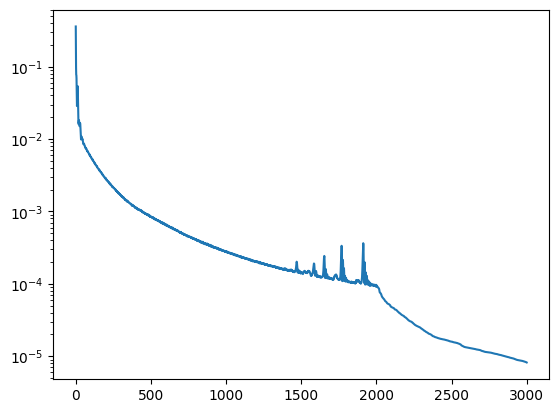

In [17]:
import matplotlib.pyplot as plt
plt.plot(losses)
plt.yscale('log')

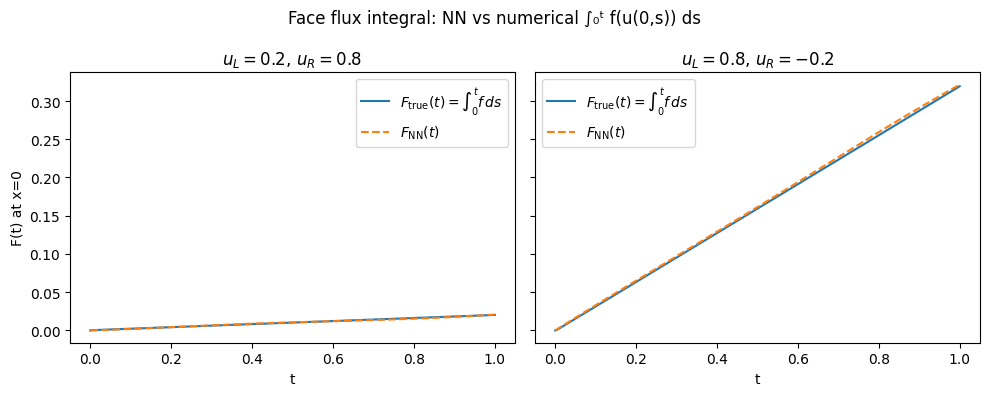

In [8]:
import matplotlib.pyplot as plt

t_plot = jnp.linspace(0.0, 1.0, 200)


def F_true_time(t, uL, uR):
    flux_at_t = jax.vmap(lambda ti: flux(utrue_at_face(ti, uL, uR)))(t)
    # trapezoidal cumsum: F(t_i) = ∫_0^{t_i} f(s) ds
    increments = 0.5 * (flux_at_t[:-1] + flux_at_t[1:]) * jnp.diff(t)
    return jnp.concatenate([jnp.array([0.0]), jnp.cumsum(increments)])


def F_nn_time(t, uL, uR):
    x = jnp.stack([t, jnp.full_like(t, uL), jnp.full_like(t, uR)], axis=-1)
    return jax.vmap(lambda row: row[0] * F_net(row))(x)


pairs = [(0.2, 0.8), (0.8, -0.2)]
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, (uL, uR) in zip(axes, pairs):
    F_exact = F_true_time(t_plot, uL, uR)
    F_pred = F_nn_time(t_plot, uL, uR)
    ax.plot(t_plot, F_exact, label=r"$F_{\mathrm{true}}(t)=\int_0^t f\,ds$")
    ax.plot(t_plot, F_pred, "--", label=r"$F_{\mathrm{NN}}(t)$")
    ax.set_xlabel("t")
    ax.set_title(f"$u_L={uL}$, $u_R={uR}$")
    ax.legend()

axes[0].set_ylabel("F(t) at x=0")
fig.suptitle("Face flux integral: NN vs numerical ∫₀ᵗ f(u(0,s)) ds")
plt.tight_layout()
plt.show()

In [14]:
# L-BFGS on a fixed batch: value_fn(trial_params) evaluates the objective on a
# merged module so the linesearch never calls nnx.update under a JAX trace.
from jax import random as jr

import copy

if "F_net_adam" not in globals():
    F_net_adam = copy.deepcopy(F_net)
    losses_adam = copy.deepcopy(losses)

F_net = copy.deepcopy(F_net_adam)
losses = list(losses_adam)

sampler = UniformRandomSampler()
t_bounds = jnp.array([0., 1.])
uL_bounds = jnp.array([-1., 1.])
uR_bounds = jnp.array([-1., 1.])
bounds = jnp.vstack([t_bounds, uL_bounds, uR_bounds])

batch_size = 2**17
key = jr.PRNGKey(42)
x_batch = sampler.draw_batch(key, batch_size, 3, bounds)

opt_lbfgs = nnx.Optimizer(F_net, optax.lbfgs(), wrt=nnx.Param)


def loss_lbfgs(m):
    return loss(x_batch, m)


def lbfgs_step(net, optimizer):
    graphdef, _, rest = nnx.split(net, nnx.Param, ...)
    loss_val, grads = nnx.value_and_grad(loss_lbfgs)(net)

    def value_fn(trial_params):
        return loss_lbfgs(nnx.merge(graphdef, trial_params, rest))

    optimizer.update(
        net,
        grads,
        value=loss_val,
        grad=grads,
        value_fn=value_fn,
    )
    return float(loss_lbfgs(net)), net


n_lbfgs = 1000
pbar = tqdm(range(n_lbfgs))
for _ in pbar:
    lv, F_net = lbfgs_step(F_net, opt_lbfgs)
    losses.append(lv)
    pbar.set_postfix(loss=losses[-1])

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [20:20<00:00,  1.22s/it, loss=8.21e-6]


full       (t<1.0, |u|<=1.0)              : L2=1.547003e-03  Linf=1.869386e-02
restricted (t<0.8, |u|<=0.8)              : L2=1.059807e-03  Linf=1.266915e-02
small jump (|du/u|<=1e-2, |u| in [0.1, 0.99]): L2=1.285892e-03  Linf=3.763840e-03


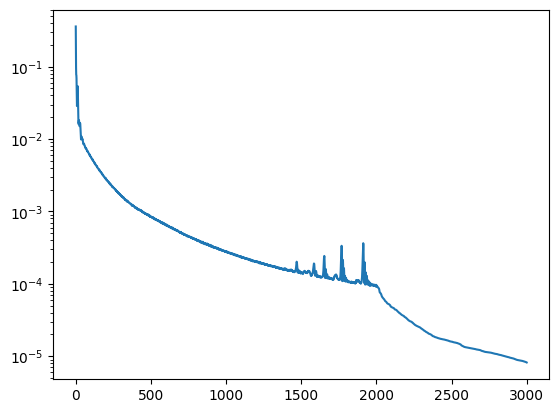

In [ ]:
import matplotlib.pyplot as plt
plt.plot(losses)
plt.yscale('log')

def F_true_at(t, uL, uR):
    return t * flux(utrue_at_face(0.1, uL, uR))

def errors_on(x_eval):
    F_pred = jax.vmap(lambda row: row[0] * F_net(row))(x_eval)
    F_exact = jax.vmap(F_true_at)(x_eval[..., 0], x_eval[..., 1], x_eval[..., 2])
    err = F_pred - F_exact
    l2 = float(jnp.sqrt(jnp.mean(err ** 2)))
    linf = float(jnp.max(jnp.abs(err)))
    return l2, linf


def eval_errors(eval_bounds, label, batch_size=2**17, key=jr.PRNGKey(123)):
    x_eval = sampler.draw_batch(key, batch_size, 3, eval_bounds)
    l2, linf = errors_on(x_eval)
    print(f"{label}: L2={l2:.6e}  Linf={linf:.6e}")


def eval_small_jumps(label, batch_size=2**17, key=jr.PRNGKey(456),
                     u_min=0.1, u_max=0.8, max_ratio=1e-2, t_max=1.0):
    # |u_avg| in [u_min, u_max] with random sign; delta_u = r * |u_avg|,
    # r ~ U(-max_ratio, max_ratio) so |delta_u / u_avg| <= max_ratio.
    k_t, k_mag, k_sign, k_r = jr.split(key, 4)
    t = jr.uniform(k_t, (batch_size,), minval=0., maxval=t_max)
    u_mag = jr.uniform(k_mag, (batch_size,), minval=u_min, maxval=u_max)
    u_sign = jnp.where(jr.uniform(k_sign, (batch_size,)) < 0.5, -1.0, 1.0)
    u_avg = u_sign * u_mag
    delta_u = jr.uniform(k_r, (batch_size,), minval=-max_ratio, maxval=max_ratio) * u_mag
    uL = u_avg - 0.5 * delta_u
    uR = u_avg + 0.5 * delta_u
    x_eval = jnp.stack([t, uL, uR], axis=-1)
    l2, linf = errors_on(x_eval)
    print(f"{label}: L2={l2:.6e}  Linf={linf:.6e}")


full_bounds = jnp.array([[0., 1.], [-1., 1.], [-1., 1.]])
restricted_bounds = jnp.array([[0., 0.8], [-0.8, 0.8], [-0.8, 0.8]])

eval_errors(full_bounds, "full       (t<1.0, |u|<=1.0)              ")
eval_errors(restricted_bounds, "restricted (t<0.8, |u|<=0.8)              ")
eval_small_jumps("small jump (|du/u|<=1e-2, |u| in [0.1, 0.99])")

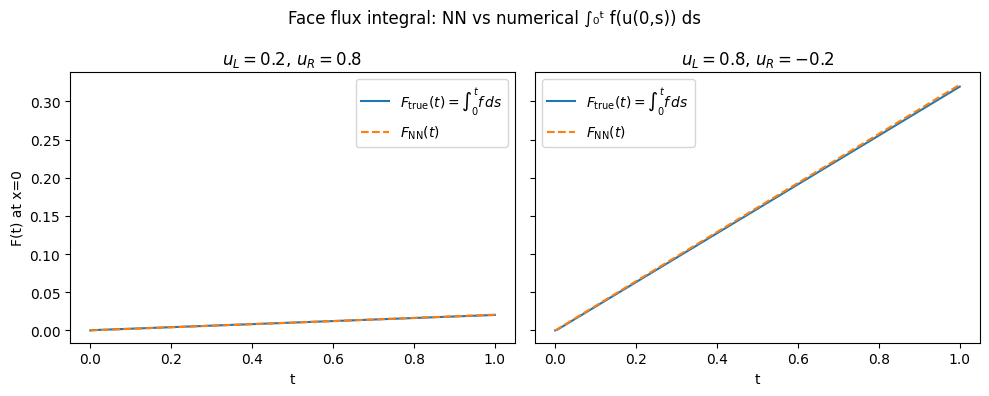

In [18]:
import matplotlib.pyplot as plt

t_plot = jnp.linspace(0.0, 1.0, 200)


def F_true_time(t, uL, uR):
    flux_at_t = jax.vmap(lambda ti: flux(utrue_at_face(ti, uL, uR)))(t)
    # trapezoidal cumsum: F(t_i) = ∫_0^{t_i} f(s) ds
    increments = 0.5 * (flux_at_t[:-1] + flux_at_t[1:]) * jnp.diff(t)
    return jnp.concatenate([jnp.array([0.0]), jnp.cumsum(increments)])


def F_nn_time(t, uL, uR):
    x = jnp.stack([t, jnp.full_like(t, uL), jnp.full_like(t, uR)], axis=-1)
    return jax.vmap(lambda row: row[0] * F_net(row))(x)


pairs = [(0.2, 0.8), (0.8, -0.2)]
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, (uL, uR) in zip(axes, pairs):
    F_exact = F_true_time(t_plot, uL, uR)
    F_pred = F_nn_time(t_plot, uL, uR)
    ax.plot(t_plot, F_exact, label=r"$F_{\mathrm{true}}(t)=\int_0^t f\,ds$")
    ax.plot(t_plot, F_pred, "--", label=r"$F_{\mathrm{NN}}(t)$")
    ax.set_xlabel("t")
    ax.set_title(f"$u_L={uL}$, $u_R={uR}$")
    ax.legend()

axes[0].set_ylabel("F(t) at x=0")
fig.suptitle("Face flux integral: NN vs numerical ∫₀ᵗ f(u(0,s)) ds")
plt.tight_layout()
plt.show()